# Single Variable Experiments

In [8]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler

# Plotting defaults for consistency and accessibility
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.get_cmap('Set2').colors)

from src.single_variable.bisection import bisection
from src.single_variable.secant import secant
from src.single_variable.newton import newton
from src.single_variable.damped_newton import damped_newton
from src.single_variable.brent import brent


/var/folders/rc/c14qrm5n3_g6ps2wp3vqjbm40000gn/T/ipykernel_6805/1733145791.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.get_cmap('Set2').colors)


In [10]:
def extract_history_residuals(result):
    residuals = []

    for step in result["history"]:
        if "residual" in step:
            residuals.append(abs(float(step["residual"])))
        elif "fx" in step:
            residuals.append(abs(float(step["fx"])))
        elif "f_curr" in step:
            residuals.append(abs(float(step["f_curr"])))
        elif "fb" in step:
            residuals.append(abs(float(step["fb"])))
        elif "norm_f" in step:
            residuals.append(abs(float(step["norm_f"])))

    return residuals


def residuals_for_plot(result, atol=1e-12, rtol=1e-12, eps=1e-16):
    residuals = extract_history_residuals(result)

    final_residual = abs(float(result["final_residual"]))

    if not residuals or not np.isclose(residuals[-1], final_residual, atol=atol, rtol=rtol):
        residuals.append(final_residual)

    return [max(r, eps) for r in residuals]


def residual_consistency_report(results_dict):
    rows = []

    for name, result in results_dict.items():
        history_residuals = extract_history_residuals(result)
        plot_residuals = residuals_for_plot(result)

        history_last = history_residuals[-1] if history_residuals else None
        plot_last = plot_residuals[-1] if plot_residuals else None
        final_residual = abs(float(result["final_residual"]))

        rows.append({
            "Method": name,
            "Iterations": result["iterations"],
            "History Last Residual": history_last,
            "Final Residual": final_residual,
            "Plot Last Residual": plot_last,
            "Matches": np.isclose(plot_last, final_residual, atol=1e-12, rtol=1e-12),
            "Converged": result["converged"],
        })

    return pd.DataFrame(rows)

In [11]:
def f(x):
    return np.cos(x) - x


def df(x):
    return -np.sin(x) - 1

result_newton = newton(f, df, x0=1.5)

In [12]:
methods = {
    "Bisection": bisection(f, 0.0, 1.0),
    "Secant": secant(f, 0.0, 1.0),
    "Newton": newton(f, df, 0.5),
    "Damped Newton": damped_newton(f, df, 0.5),
    "Brent": brent(f, 0.0, 1.0),
}

summary = []

for name, result in methods.items():
    summary.append({
        "Method": name,
        "Root": result["root"],
        "Converged": result["converged"],
        "Iterations": result["iterations"],
        "Final Error": result["final_error"],
        "Final Residual": result["final_residual"],
        "Message": result["message"],
    })

df_summary = pd.DataFrame(summary)
df_summary

,Method,Root,Converged,Iterations,Final Error,Final Residual,Message
0,Bisection,0.739085,True,24,5.960464e-08,7.747025e-09,converged by residual tolerance
1,Secant,0.739085,True,5,2.108754e-08,2.667866e-13,converged by residual tolerance
2,Newton,0.739085,True,3,5.653223e-05,1.180978e-09,converged by residual tolerance
3,Damped Newton,0.739085,True,11,1.373717e-08,5.747675e-09,converged by residual tolerance
4,Brent,0.739085,True,5,2.964360e-06,6.109329e-09,converged by residual tolerance


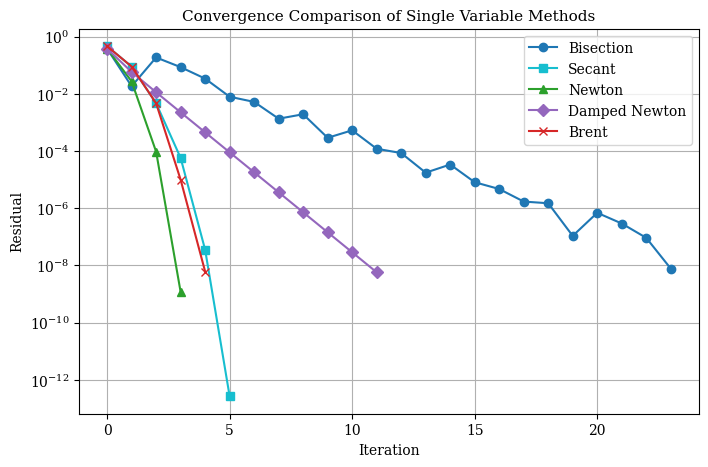

In [13]:
plt.figure(figsize=(8, 5))

# Use same palette as armijo_residual (no yellow/orange)
armijo_palette = [
    '#1f77b4',  # blue
    '#17becf',  # cyan
    '#2ca02c',  # green
    '#9467bd',  # purple
    '#4daf4a',  # darker green
    '#7b4173',  # magenta-ish
    '#3182bd',  # steel blue
    '#66c2a5',  # teal
]

# Ensure we have at least as many distinct colors as methods
palette = armijo_palette
method_colors = dict(zip(methods.keys(), palette))
# Set Brent specifically to red
if 'Brent' in method_colors:
    method_colors['Brent'] = '#d62728'  # red

markers = ['o', 's', '^', 'D', 'x', 'v', '>', '<']

for (name, result), m in zip(methods.items(), markers):
    residuals = residuals_for_plot(result)

    if residuals:
        plt.semilogy(
            range(len(residuals)),
            residuals,
            marker=m,
            color=method_colors.get(name, '#000000'),
            label=name,
            linewidth=1.5
        )

plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("Convergence Comparison of Single Variable Methods")

plt.legend()
plt.grid(True)

plt.savefig(
    "../latex/figures/single_variable_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [14]:
residual_consistency_report(methods)

,Method,Iterations,History Last Residual,Final Residual,Plot Last Residual,Matches,Converged
0,Bisection,24,7.747025e-09,7.747025e-09,7.747025e-09,True,True
1,Secant,5,3.529262e-08,2.667866e-13,2.667866e-13,True,True
2,Newton,3,9.461538e-05,1.180978e-09,1.180978e-09,True,True
3,Damped Newton,11,2.873838e-08,5.747675e-09,5.747675e-09,True,True
4,Brent,5,6.109329e-09,6.109329e-09,6.109329e-09,True,True
